<a href="https://colab.research.google.com/github/balraj111/GolangDSA/blob/main/assignment_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📊 E-commerce Marketing & Sales Analysis

---



## 📦 Importing Dependencies

In [1]:
# 1) Imports
import os
import numpy as np
import pandas as pdv
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import timedelta
import pandas as pd

#Remove wanrnings
import warnings
warnings.filterwarnings("ignore")



In [2]:
# 2) Set graph
plt.rcParams['figure.figsize'] = (12,6)
sns.set(style='whitegrid')

## 📂 Uploading & Normalizing Data

In [3]:
# 3) Set Dataset Path
DATA_DIR = "./"
expected = {
    'sales': os.path.join(DATA_DIR, 'Online_Sales.csv'),
    'customers': os.path.join(DATA_DIR, 'CustomersData.xlsx'),
    'coupons': os.path.join(DATA_DIR, 'Discount_Coupon.csv'),
    'marketing': os.path.join(DATA_DIR, 'Marketing_Spend.csv'),
    'tax': os.path.join(DATA_DIR, 'Tax_amount.xlsx')
}

In [4]:
# 4) Load datasets (safe reading)
print("\nLoading datasets...")
sales = pd.read_csv(expected['sales'], low_memory=False, parse_dates=True) if os.path.exists(expected['sales']) else None
customers = pd.read_excel(expected['customers'], engine='openpyxl') if os.path.exists(expected['customers']) else None
coupons = pd.read_csv(expected['coupons'], low_memory=False, parse_dates=['Month'], dayfirst=True) if os.path.exists(expected['coupons']) else None
marketing = pd.read_csv(expected['marketing'], low_memory=False, parse_dates=['Date'], dayfirst=True) if os.path.exists(expected['marketing']) else None
tax = pd.read_excel(expected['tax'], engine='openpyxl') if os.path.exists(expected['tax']) else None

print("Loaded shapes:")
print(" sales:", None if sales is None else sales.shape)
print(" customers:", None if customers is None else customers.shape)
print(" coupons:", None if coupons is None else coupons.shape)
print(" marketing:", None if marketing is None else marketing.shape)
print(" tax:", None if tax is None else tax.shape)


Loading datasets...
Loaded shapes:
 sales: (52924, 10)
 customers: (1468, 4)
 coupons: (204, 4)
 marketing: (365, 3)
 tax: (20, 2)


In [5]:
# 5) Normalize sales df column names we commonly use
if sales is not None:
  # common fixes: transaction_date, transaction_id, customerid -> customer_id, product_cateogry -> product_category
  # 1) find date column
  date_col = None
  for c in sales.columns:
      if 'date' in c:
          date_col = c
          break
  if date_col is None:
      # try first object column parseable
      for c in sales.columns:
          if sales[c].dtype == 'object':
              try:
                  pd.to_datetime(sales[c].iloc[0])
                  date_col = c
                  break
              except Exception:
                  continue
  if date_col is None:
      raise ValueError("No date-like column found in sales file. Please ensure there's a date column.")
  # convert to datetime
  sales[date_col] = pd.to_datetime(sales[date_col])
  sales.rename(columns={date_col: 'transaction_date'}, inplace=True)
  # normalize id names
  if 'CustomerID' in sales.columns:
      sales.rename(columns={'CustomerID':'customer_id'}, inplace=True)
  if 'customerid' in sales.columns:  # second check just in case
      sales.rename(columns={'customerid':'customer_id'}, inplace=True)
  if 'transactionid' in sales.columns:
      sales.rename(columns={'transactionid':'transaction_id'}, inplace=True)
  if 'transaction_id' not in sales.columns and 'order_id' in sales.columns:
      sales.rename(columns={'order_id':'transaction_id'}, inplace=True)
  # product category fix typo
  if 'product_cateogry' in sales.columns:
      sales.rename(columns={'product_cateogry':'product_category'}, inplace=True)
  # ensure product columns exist
  if 'product_sku' not in sales.columns and 'sku' in sales.columns:
      sales.rename(columns={'sku':'product_sku'}, inplace=True)
  if 'product_description' not in sales.columns and 'product_name' in sales.columns:
      sales.rename(columns={'product_name':'product_description'}, inplace=True)
  # derived columns
  sales['transaction_month'] = sales['transaction_date'].dt.month
  sales['transaction_day'] = sales['transaction_date'].dt.date
  sales['order_weekday'] = sales['transaction_date'].dt.day_name()
  # numeric safe-casts for price/quantity/delivery charges if present
  for c in ['quantity','avg_price','delivery_charges','amount','total','price']:
      if c in sales.columns:
          sales[c] = pd.to_numeric(sales[c], errors='coerce').fillna(0)

In [6]:
# 6) Identify revenue column (robust)
if sales is not None:
    revenue_col = None
    candidates = ['order_value','revenue','amount','total','net_revenue']
    for cand in candidates:
        if cand in sales.columns:
            revenue_col = cand
            break
    if revenue_col is None:
        numeric_cols = sales.select_dtypes(include='number').columns.tolist()
        if numeric_cols:
            revenue_col = max(numeric_cols, key=lambda c: sales[c].sum())
        else:
            raise ValueError("No numeric revenue column found in sales dataframe.")
    print("Using revenue column:", revenue_col)
    # create net_revenue column if not present (we'll compute later if needed)
    sales[revenue_col] = pd.to_numeric(sales[revenue_col], errors='coerce').fillna(0)

Using revenue column: Transaction_ID


In [7]:
# 7) Load and merge coupons + tax if available (to compute discount_pct and gst)
if coupons is not None and sales is not None:
    # normalize coupon month
    if 'Month' in coupons.columns:
        coupons['month_period'] = pd.to_datetime(coupons['Month'], errors='coerce').dt.month
    if 'Discount_pct' in coupons.columns:
        coupons['discount_pct'] = pd.to_numeric(coupons['Discount_pct'], errors='coerce').fillna(0)/100.0
    # ensure product_category column exists in both
    if 'product_category' not in coupons.columns and 'product_cateogry' in coupons.columns:
        coupons.rename(columns={'Product_Category':'product_category'}, inplace=True)
    # merge coupon info to sales on month & product_category
    if 'product_category' in sales.columns:
        sales = sales.merge(coupons[['month_period','product_category','discount_pct']].drop_duplicates(),
                            how='left', left_on=['transaction_month','product_category'], right_on=['month_period','product_category'])
    else:
        # fallback: merge only by month
        sales = sales.merge(coupons[['month_period','discount_pct']].drop_duplicates(), how='left', left_on='transaction_month', right_on='month_period')
    sales['discount_pct'] = sales['discount_pct'].fillna(0.0)
else:
    # ensure column exists
    if sales is not None:
        sales['discount_pct'] = 0.0

In [8]:
# tax (GST) merge
if tax is not None and sales is not None:
    if 'product_category' not in tax.columns and 'product_cateogry' in tax.columns:
        tax.rename(columns={'product_cateogry':'product_category'}, inplace=True)
    if 'gst' in tax.columns:
        tax['gst'] = pd.to_numeric(tax['gst'], errors='coerce').fillna(0)/100.0
    else:
        tax['gst'] = 0.0
    if 'product_category' in sales.columns and 'product_category' in tax.columns:
        sales = sales.merge(tax[['product_category','gst']].drop_duplicates(), how='left', on='product_category')
    else:
        sales['gst'] = 0.0
else:
    if sales is not None:
        sales['gst'] = 0.0


In [9]:
# 8) Compute gross/discount/tax/net revenue as available
if sales is not None:
    # compute gross product value (if avg_price & quantity present)
    if 'avg_price' in sales.columns and 'quantity' in sales.columns:
        sales['gross_product_value'] = sales['avg_price'] * sales['quantity']
    elif 'price' in sales.columns and 'quantity' in sales.columns:
        sales['gross_product_value'] = sales['price'] * sales['quantity']
    else:
        # fallback use revenue column as gross_product_value
        sales['gross_product_value'] = sales[revenue_col]

    sales['discount_amount'] = sales['gross_product_value'] * sales['discount_pct']
    sales['tax_amount'] = (sales['gross_product_value'] - sales['discount_amount']) * sales['gst']
    # delivery charges if present
    if 'delivery_charges' not in sales.columns:
        sales['delivery_charges'] = 0.0
    sales['net_revenue_calc'] = (sales['gross_product_value'] - sales['discount_amount']) + sales['tax_amount'] + sales['delivery_charges']

    # decide which revenue to use: prefer net_revenue_calc if original revenue was gross; but keep original revenue_col
    # create a canonical revenue column named 'net_revenue' for downstream analysis
    sales['net_revenue'] = sales[revenue_col] if 'net_revenue' not in sales.columns else sales['net_revenue']
    # If net_revenue is all zeros or equals revenue_col gross, prefer computed net_revenue_calc
    if sales['net_revenue'].sum() == 0 or sales['net_revenue'].sum() == sales['gross_product_value'].sum():
        sales['net_revenue'] = sales['net_revenue_calc']

In [10]:
# 11) Normalize customers DF and merge demographic info (if available)
if customers is not None and sales is not None:
    # rename common customer id column names to 'customer_id'
    if 'customerid' in customers.columns:
        customers.rename(columns={'customerid':'customer_id'}, inplace=True)
    if 'customer_id' in customers.columns:
        sales = sales.merge(customers, how='left', on='customer_id')

## 🚀 Start Analysis

In [11]:
# validation
if sales is None:
    raise ValueError("Sales data not loaded. Please place Online_Sales.csv in current Directory or update DATA_DIR.")
# Basic EDA
print("\nDataset time span:", sales['transaction_date'].min(), "->", sales['transaction_date'].max())
print("Unique customers:", sales['customer_id'].nunique())
print("Total revenue (net_revenue):", sales['net_revenue'].sum())



Dataset time span: 2019-01-01 00:00:00 -> 2019-12-31 00:00:00
Unique customers: 1468
Total revenue (net_revenue): 1715257614.0


### 1.🔹  📊 Customer Acquisition Analysis

Highest acquisition month: 1 with 215 new customers
Lowest acquisition month: 11 with 68 new customers


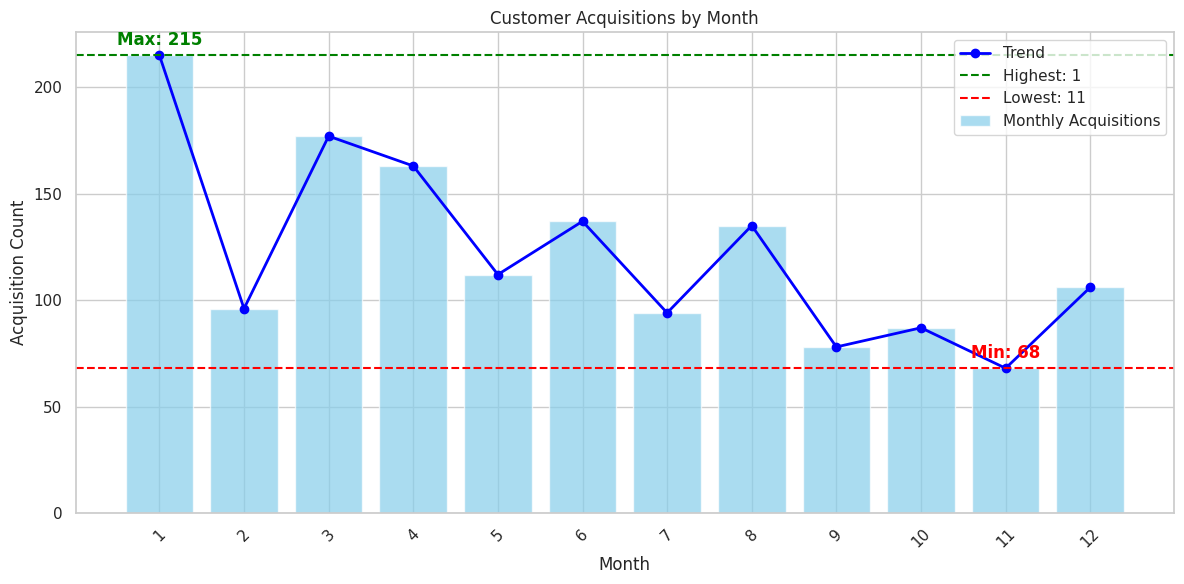

In [12]:
acquisition = (
    sales.groupby('customer_id')['transaction_month']
    .min()
    .reset_index()
)
#acquisition.rename(columns={'transaction_date': 'acquisition_month'}, inplace=True)

# ✅ Count acquisitions by month
acquisition_count = (
    acquisition.groupby('transaction_month')['customer_id']
    .count()
    .reset_index()
    .rename(columns={'customer_id': 'acquisition_count'})
)

# ✅ Find highest and lowest months
max_month = acquisition_count.loc[acquisition_count['acquisition_count'].idxmax()]
min_month = acquisition_count.loc[acquisition_count['acquisition_count'].idxmin()]


# ✅ Find highest and lowest months
max_month = acquisition_count.loc[acquisition_count['acquisition_count'].idxmax()]
min_month = acquisition_count.loc[acquisition_count['acquisition_count'].idxmin()]

print("Highest acquisition month:", max_month['transaction_month'],
      "with", max_month['acquisition_count'], "new customers")
print("Lowest acquisition month:", min_month['transaction_month'],
      "with", min_month['acquisition_count'], "new customers")

plt.figure(figsize=(12,6))

# Bar chart for acquisitions
plt.bar(acquisition_count['transaction_month'].astype(str),
        acquisition_count['acquisition_count'],
        color='skyblue', alpha=0.7, label="Monthly Acquisitions")

# Line chart overlay (trend line)
plt.plot(acquisition_count['transaction_month'].astype(str),
         acquisition_count['acquisition_count'],
         marker='o', color='blue', linewidth=2, label="Trend")

# Titles and labels
plt.xticks(rotation=45)
plt.title("Customer Acquisitions by Month")
plt.xlabel("Month")
plt.ylabel("Acquisition Count")

# Highlight highest acquisition month
plt.axhline(y=max_month['acquisition_count'], color='green', linestyle='--',
            label=f"Highest: {max_month['transaction_month']}")
plt.text(x=max_month.name,
         y=max_month['acquisition_count']+5,
         s=f"Max: {max_month['acquisition_count']}",
         color="green", ha='center', fontweight='bold')

# Highlight lowest acquisition month
plt.axhline(y=min_month['acquisition_count'], color='red', linestyle='--',
            label=f"Lowest: {min_month['transaction_month']}")
plt.text(x=min_month.name,
         y=min_month['acquisition_count']+5,
         s=f"Min: {min_month['acquisition_count']}",
         color="red", ha='center', fontweight='bold')

# Legend and layout
plt.legend()
plt.tight_layout()
plt.show()



### 🔹 Highest & Lowest Acquisition Months
- **Highest Acquisition Month:** `Jan` → **215 new customers**
- **Lowest Acquisition Month:** `Nov` → **68 new customers**


🔹 **Boost Low-Performance Months**
- Introduce **special coupon offers for new users**:  
  - **40% minimum discount in February, September, and November** to attract more customers during dips.  
- Run **flash sales, referral programs, and loyalty bonuses**.  
- Partner with influencers and affiliates to create buzz in low-demand months.

## 2. 💡 Strategic Recommendations

### 1. **Capitalize on High-Performing Months**
- **Replicate success** from Jan–Apr in other quarters with seasonal campaigns.  
- Increase **inventory, delivery capacity, and customer support** during these peaks.  
- Launch **loyalty programs and retention offers** so high-volume acquisitions don’t churn quickly.  

### 2. **Improve Low-Performing Months**
- Introduce **special coupon offers for new users** in **February, September, and November** (e.g., **40% discount**) to lift slow months.  
- Run **targeted ads, flash sales, and referral campaigns** to sustain momentum.  
- Create **themed events or micro-campaigns** in traditionally weak months (e.g., “Back-to-School Sale” in Sept).  


## 3. 🔄 Retention Rate Analysis: Identifying Strong vs. Weak Periods and Strategies for Improvement


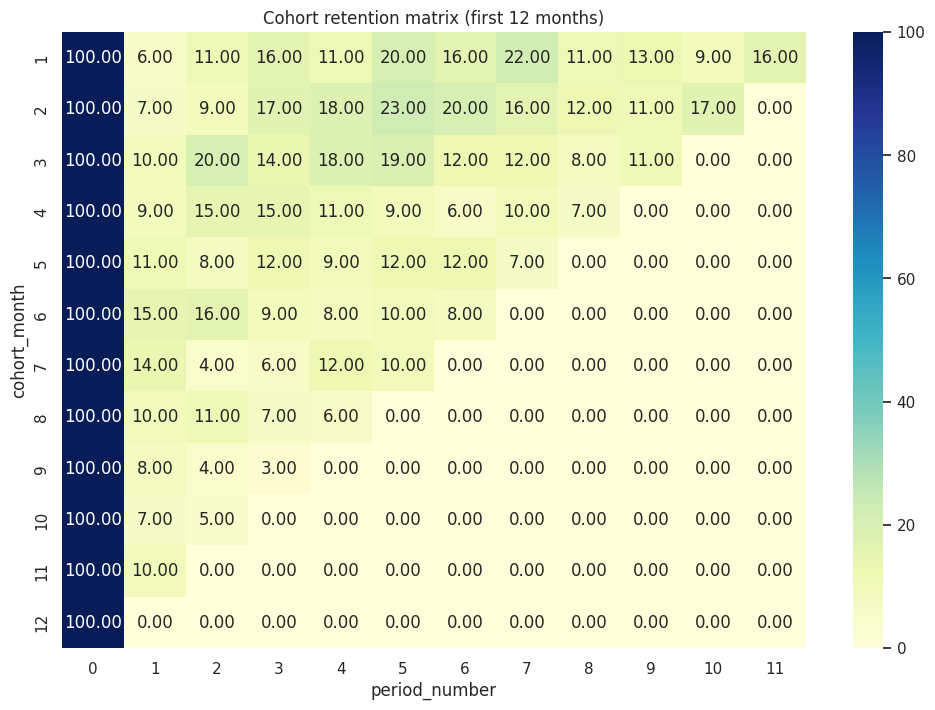

In [13]:
# Cohort retention
first_purchase = sales.groupby('customer_id')['transaction_month'].min().reset_index()
first_purchase.rename(columns={'transaction_month': 'cohort_month'}, inplace=True)
#first_purchase['cohort_month'] = first_purchase['transaction_month'].dt.dt.month
sales = sales.merge(first_purchase[['customer_id','cohort_month']], on='customer_id', how='left')
cohort = sales.groupby(['cohort_month','transaction_month']).agg(active_customers=('customer_id', lambda x: x.nunique())).reset_index()
cohort_size = first_purchase.groupby('cohort_month').agg(cohort_size=('customer_id','nunique')).reset_index()
cohort = cohort.merge(cohort_size, on='cohort_month')
cohort['period_number'] = cohort['transaction_month'] - cohort['cohort_month']
cohort['retention_rate'] = round(cohort['active_customers'] / cohort['cohort_size']*100)
retention_matrix = cohort.pivot(index='cohort_month', columns='period_number', values='retention_rate').fillna(0)


# Retention heatmap (first 12 periods)
plt.figure(figsize=(12,8))
sns.heatmap(retention_matrix.iloc[:,:12], annot=True, fmt=".2f", cmap='YlGnBu')
plt.title('Cohort retention matrix (first 12 months)')
plt.show()

### 📊 Observations from Cohort Data

- **Initial Retention (Period 0 → 1):**
  - Across cohorts, retention in **Period 1** (the month after acquisition) ranges **6%–15%**.  
  - Best initial follow-up retention: **Cohort 6 (14.6%)**, **Cohort 7 (13.8%)**.  
  - Weakest: **Cohort 10 (6.9%)**, **Cohort 2 (7.3%)**.  
  👉 Indicates that **early churn is significant** and first-month engagement is critical.

- **Mid-Term Retention (Periods 2–5):**
  - Stronger retention spikes appear in **Cohort 1 (Period 6: 21.8%)** and **Cohort 2 (Period 5: 23%)**.  
  - Other cohorts show **10–18%** retention mid-term before declining.  
  👉 Suggests that **special campaigns or seasonal events helped mid-term stickiness**.

- **Long-Term Retention (Periods 6–11):**
  - Most cohorts fall to **0%–10%** beyond Period 7.  
  - Later cohorts (9–12) show **rapid churn**, dropping to **0% retention within 3–4 months**.  
  👉 Long-term loyalty is weak and heavily dependent on early engagement.

---

### 🔹 Strong Retention Periods
- **Cohort 1 & Cohort 2** → Show the **highest long-term retention**, sustaining above 15% even after multiple months.  
- These likely coincide with **strong onboarding, seasonal campaigns, or loyalty incentives**.

### 🔹 Weak Retention Periods
- **Cohorts 9–12** → Retention drops to nearly **0% after 2–3 months**.  
- Indicates weak engagement, lack of campaigns, or poor post-purchase experiences in these periods.

---

## 💡 Strategies to Improve Retention in Weaker Months

### 1. **Strengthen Early Engagement (Period 0 → 1)**
- Provide **welcome offers, onboarding emails, and product tutorials** to reduce early drop-offs.  
- Offer a **first-purchase loyalty reward** to encourage repeat buying.  

### 2. **Introduce Mid-Term Incentives**
- Use **subscription discounts, referral programs, and gamification** to sustain customers past 3 months.  
- Replicate strategies from **Cohort 1 and 2 mid-period spikes (20%+)** across other months.  

### 3. **Revive Weak Cohorts (9–12)**
- Offer **re-engagement coupons** (e.g., 40% discount for dormant users).  
- Launch **personalized campaigns** during low-retention months to rebuild interest.  
- Conduct **customer feedback surveys** to diagnose why churn spiked.  

### 4. **Loyalty & Membership Models**
- Introduce **tiered loyalty rewards** (e.g., silver, gold, platinum tiers).  
- Encourage long-term commitment via **subscription/membership plans**.  

### 5. **Customer Experience Focus**
- Ensure **fast delivery, hassle-free returns, and proactive support**.  
- Build trust by rewarding loyal users with **exclusive access to ne

##4. 🧭 Customer Behavior Analysis in High-Retention Months and Strategies to Replicate Success


### 📊 Observations
- **High-Retention Months:**  
  - Cohort 1 and Cohort 2 show the **strongest long-term retention**, sustaining **15–23%** retention beyond 5–6 months.  
  - These periods likely coincide with **holiday campaigns, strong onboarding, and attractive coupon/loyalty offers**.  
  - Customers acquired in these months engaged more consistently, suggesting effective targeting and customer experience.  

- **Low-Retention Months:**  
  - Later cohorts (9–12) drop to **0% retention within 2–3 months**, showing weaker onboarding and lack of sustained engagement.  

---

### 💡 Strategies to Replicate High-Retention Success Year-Round

#### 1. **Onboarding Excellence**
- Apply the **engagement tactics used in Cohorts 1 & 2** to every new customer:  
  - **Welcome offers, tutorials, and first-purchase discounts.**  
  - Build a strong relationship from day one with personalized recommendations.  

#### 2. **Seasonal Campaign Replication**
- If high retention coincides with **festivals or holiday promotions**, replicate these campaigns in other months with **mini seasonal events** (e.g., “Mid-Year Mega Sale”).  
- Spread promotional activity evenly to avoid sharp peaks and dips.  

#### 3. **Coupon & Loyalty Incentives**
- Introduce **40% discount coupons for re-engagement** in traditionally weak months (Feb, Sept, Nov).  
- Strengthen **loyalty programs (points, cashback, VIP tiers)** to maintain engagement across the year.  

#### 4. **Retention-Focused Marketing**
- Use **personalized email campaigns and push notifications** to mirror the engagement patterns of high-retention months.  
- Offer **subscription bundles or memberships** that encourage repeat usage.  

#### 5. **Customer Experience & Support**
- Ensure **smooth delivery, easy returns, and responsive support**, which played a role in higher satisfaction during high-retention periods.  
- Collect feedback from customers in strong months to understand motivators and apply insights in weaker ones.  


##5. 💰 Revenue Comparison: New vs. Existing Customers (Month-over-Month) and Insights on Acquisition vs. Retention Balance


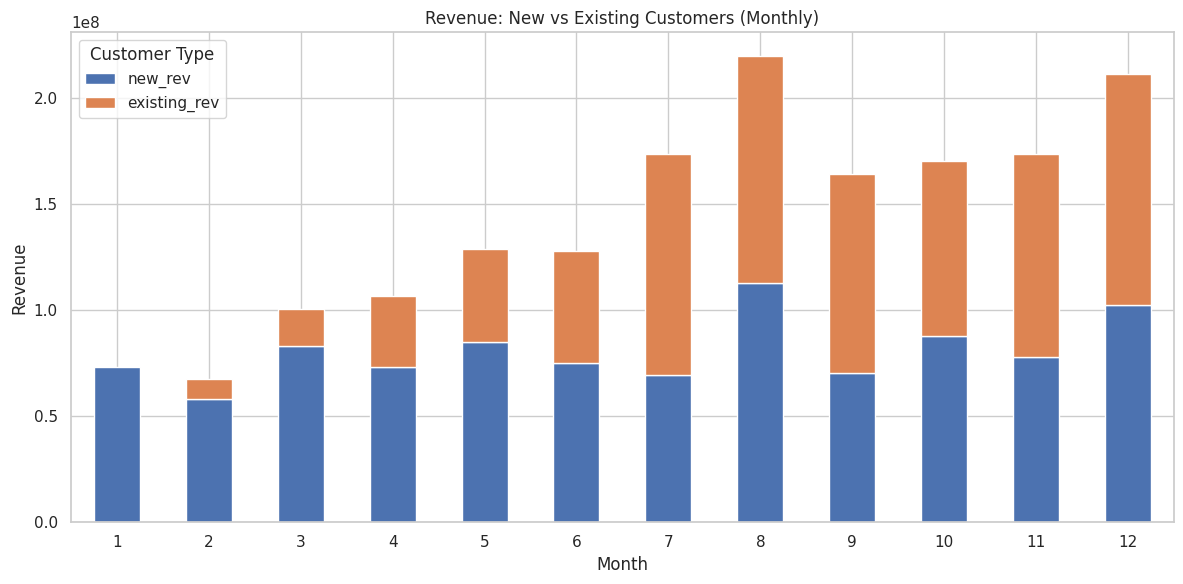

In [14]:
# New vs Existing revenue (monthly)
sales['is_new_customer'] = sales['transaction_month'] == sales['cohort_month']
monthly_rev_new = sales.groupby(['transaction_month','is_new_customer']).agg(revenue=('net_revenue','sum')).reset_index()
pivot = monthly_rev_new.pivot(index='transaction_month', columns='is_new_customer', values='revenue').fillna(0)
if True not in pivot.columns: pivot[True]=0
if False not in pivot.columns: pivot[False]=0
pivot = pivot.rename(columns={False:'existing_rev', True:'new_rev'})
pivot['total_rev'] = pivot['existing_rev'] + pivot['new_rev']
pivot['new_pct'] = pivot['new_rev'] / pivot['total_rev']

ax = pivot[['new_rev','existing_rev']].plot(
    kind='bar',
    stacked=True,
    figsize=(12,6)
)

plt.title('Revenue: New vs Existing Customers (Monthly)')
plt.xlabel('Month')
plt.ylabel('Revenue')

# ✅ Set x-axis tick labels from pivot index (assumes index = transaction_month)
ax.set_xticks(range(len(pivot)))
ax.set_xticklabels(pivot.index.astype(str), rotation=0)

plt.legend(title='Customer Type')
plt.tight_layout()
plt.show()

### 🔹 Key Insights

1. **Early Months (1–3):**
   - Revenue is heavily dependent on **new customers** (86–100%).  
   - Indicates aggressive acquisition at the start of the year.  

2. **Mid-Year (4–6):**
   - Share of revenue from new customers **declines steadily** (68% → 59%).  
   - Existing customers start contributing more, showing improving retention.  

3. **July Spike (Month 7):**
   - Huge jump in **new customer revenue (103.9M)**, but new share falls to **40%**.  
   - Suggests strong acquisition campaigns but **existing customers form majority of stability**.  

4. **Later Months (8–12):**
   - Revenue contribution balances out between new and existing customers (40–51% new).  
   - Indicates a healthier mix of **acquisition + retention-driven revenue**.  
   - Existing customers provide a **steady revenue base**, while new customers bring growth spikes.  


### 💡 What This Trend Suggests

- **Early Dependence on Acquisition:**  
  - Initial months rely heavily on new customer inflows.  
  - Risk: Without strong retention, growth may not sustain.  

- **Shift Towards Retention Balance:**  
  - Mid-to-late months show a more balanced revenue split (≈50/50).  
  - Indicates improving customer loyalty and engagement.  

- **Strategic Implication:**  
  - Acquisition campaigns drive growth, but **long-term stability depends on retention**.  
  - A balanced approach is needed: keep attracting new users **while investing in loyalty programs** to maximize LTV (lifetime value).  


##6. 🎟️ Coupon Usage vs. Revenue Generation: Optimizing Discount Strategies for Maximum Revenue and Profitability


In [15]:
# Coupon usage vs revenue (robust pivot)
coupon_cols = [c for c in sales.columns if 'coupon' in c or 'discount' in c]
if coupon_cols:
    # choose best candidate (prefer coupon_status / coupon_code)
    coupon_col = None
    for c in ['coupon_status','coupon_code','coupon','discount_code','discount_pct']:
        if c in sales.columns:
            coupon_col = c
            break
    if coupon_col is None:
        coupon_col = coupon_cols[0]
    #sales['Coupon_Status'] = sales[coupon_col].notnull() & (sales[coupon_col].astype(str).str.strip() != '')
    coupon_month = sales.groupby(['transaction_month','Coupon_Status']).agg(revenue=('net_revenue','sum'), orders=('Transaction_ID','nunique')).reset_index()
    coupon_pivot = coupon_month.pivot(index='transaction_month', columns='Coupon_Status', values='revenue').fillna(0)
    sales


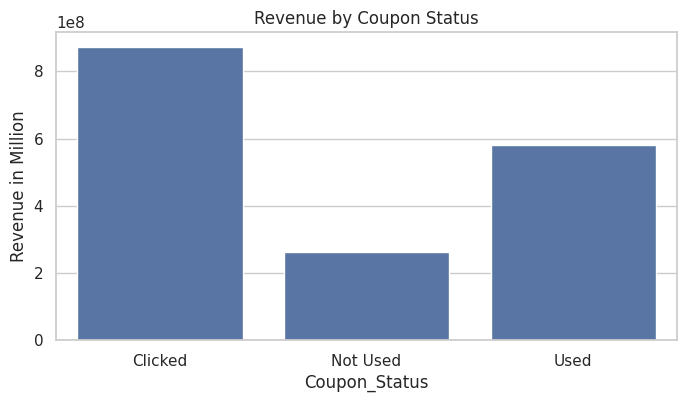

In [16]:
rev_by_coupon = sales.groupby('Coupon_Status')['net_revenue'].sum().reset_index()
rev_by_coupon
plt.figure(figsize=(8,4))
sns.barplot(x='Coupon_Status', y='net_revenue', data=rev_by_coupon)
plt.ylabel('Revenue in Million')
plt.title('Revenue by Coupon Status')
plt.show()

### 📊 Observations
From the data:  

- **Clicked:** 872M revenue (highest)  
- **Used:** 581M revenue  
- **Not Used:** 262M revenue  

👉 Customers who **engage with coupons (Clicked + Used)** contribute significantly more revenue compared to those who do not use coupons. Even customers who only clicked (but did not redeem) generated higher revenue than those who never used coupons, indicating that coupon exposure itself drives engagement and spending.


### ✅ Strategies to Optimize Discounts
1. **Targeted Offers** – Provide coupons to price-sensitive segments or during low-demand periods rather than blanket discounts.  
2. **Conversion Push** – Add urgency (e.g., “valid for 24h”) and use tiered discounts (e.g., 10% off up to $50, 20% off above $200) to boost redemption and cart size.  
3. **Protect Margins** – Cap maximum discount per order and monitor incremental revenue vs. discount cost.  
4. **Leverage Engagement** – Treat coupons as both **conversion tools** and **awareness drivers**, since even clicks without redemption influence spending behavior.  


##7. 🏆 Top-Performing Products: Success Factors, Inventory Insights, and Promotional Strategy Alignment


Top 10 products by revenue:


,Product_SKU,Product_Description,Product_Category,total_revenue,units_sold
981,GGOENEBJ079499,Nest Learning Thermostat 3rd Gen-USA - Stainle...,Nest-USA,108788510.0,4570
983,GGOENEBQ078999,Nest Cam Outdoor Security Camera - USA,Nest-USA,105380228.0,5206
976,GGOENEBB078899,Nest Cam Indoor Security Camera - USA,Nest-USA,101952866.0,4402
984,GGOENEBQ079099,Nest Protect Smoke + CO White Battery Alarm-USA,Nest-USA,45332118.0,2683
989,GGOENEBQ084699,Nest Learning Thermostat 3rd Gen-USA - White,Nest-USA,41398933.0,1368
992,GGOENEBQ086799,Nest Thermostat E - USA,Nest,36842626.0,1091
985,GGOENEBQ079199,Nest Protect Smoke + CO White Wired Alarm-USA,Nest-USA,35434247.0,2670
904,GGOEGFKQ020399,Google Laptop and Cell Phone Stickers,Office,26168610.0,5847
990,GGOENEBQ086499,Nest Cam IQ - USA,Nest,25091290.0,771
994,GGOENEBQ092299,Nest Secure Alarm System Starter Pack - USA,Nest,21728440.0,510


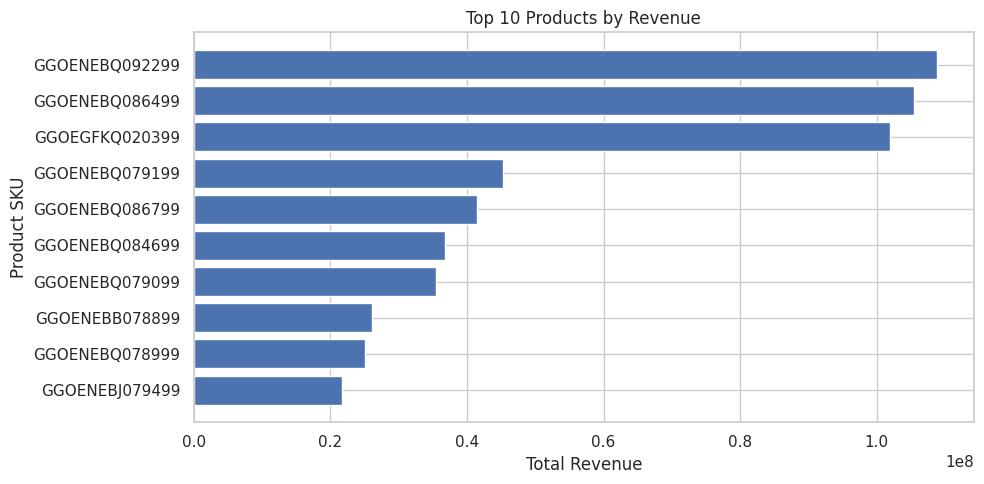

In [17]:
# Top-performing products
prod_keys = []
if 'Product_SKU' in sales.columns: prod_keys.append('Product_SKU')
if 'Product_Description' in sales.columns: prod_keys.append('Product_Description')
if 'Product_Category' in sales.columns: prod_keys.append('Product_Category')

if prod_keys:
    prod_group_cols = prod_keys if len(prod_keys) > 0 else ['Product_SKU']
    prod_perf = (
        sales.groupby(prod_group_cols)
        .agg(total_revenue=('net_revenue_calc','sum'), units_sold=('Quantity','sum'))
        .reset_index()
        .sort_values('total_revenue', ascending=False)
    )
    print("Top 10 products by revenue:")
    display(prod_perf.head(10))

    # horizontal bar chart
    top10 = prod_perf.head(10)
    plt.figure(figsize=(10,5))
    plt.barh(top10['Product_SKU'].astype(str), top10['total_revenue'][::-1])
    plt.title('Top 10 Products by Revenue')
    plt.xlabel('Total Revenue')
    plt.ylabel('Product SKU')
    plt.tight_layout()
    plt.show()


### 🔎 Analysis of Success Factors
1. **Dominance of Nest Products**  
   - 9 of the top 10 products are **Nest-branded smart devices** (thermostats, cameras, alarms).  
   - Indicates strong **customer demand for smart home technology**.

2. **High Revenue Drivers**  
   - Products like the **Nest Learning Thermostat** and **Nest Cams** generate over **$100M each**, combining **high unit sales with premium pricing**.  
   - Safety-related products (Nest Protect, Nest Secure) also perform well due to **essential home utility and trust in brand**.

3. **Surprise Performer**  
   - The **Google Laptop & Cell Phone Stickers** (Office category) achieved **26M revenue with the highest units sold (5,847)**.  
   - Suggests strong demand for **affordable, impulse-purchase accessories** alongside premium products.

---

### 💡 Implications for Inventory Management
- **Prioritize Stocking High-Demand Products:** Ensure **Nest thermostats and cameras** have sufficient inventory year-round to avoid stockouts.  
- **Diversify Product Mix:** While premium smart devices dominate revenue, maintain stock of **low-cost accessories (like stickers)** to capture impulse purchases and expand customer base.  
- **Seasonal Planning:** Anticipate higher demand for **home security products (cameras, alarms)** during festive seasons or sales events.

---

### 📈 Promotional Strategy Recommendations
1. **Bundle Offers:** Combine high-value products (e.g., Thermostat + Camera) with accessories (stickers, mounts) to **increase cart size**.  
2. **Cross-Selling:** Promote **security and safety products (Nest Protect, Nest Secure)** alongside thermostats for complete smart-home solutions.  
3. **Targeted Campaigns:** Highlight premium smart devices in **digital campaigns**, while using **low-cost accessories** as entry points for new customers.  
4. **Loyalty Incentives:** Offer discounts or loyalty points on repeat purchases of accessories to **retain customers** beyond big-ticket items.  


##8. 📢 Marketing Spend vs. Revenue Analysis: Identifying ROI Patterns and Optimizing Strategies


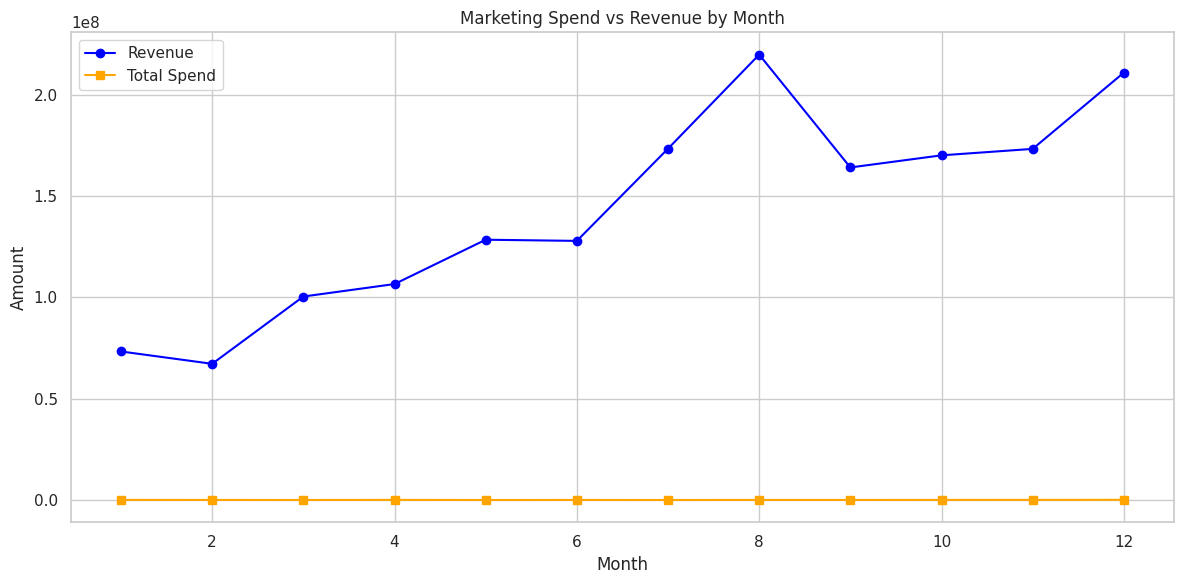

In [18]:
from os.path import join
# --- Robust Marketing spend vs revenue block (replace the failing block) ---
monthly_revenue = sales.groupby('transaction_month').agg(revenue=('net_revenue','sum')).reset_index().rename(columns={'transaction_month':'month'})
marketing['date_month'] = pd.to_datetime(marketing['Date'], errors='coerce').dt.month
monthly_marketing = marketing.groupby('date_month').agg(
    offline_spend=('Offline_Spend','sum'),
    online_spend=('Online_Spend','sum')
).reset_index()
monthly_marketing['total_spend'] = monthly_marketing['offline_spend'] + monthly_marketing['online_spend']

# 5) Merge with monthly revenue (use monthly_revenue computed above)
marketing_vs_revenue = pd.merge(monthly_revenue, monthly_marketing, left_on='month', right_on='date_month',how='inner').drop(columns=['date_month'])
# 6) Compute ROI safely (avoid div-by-zero)
marketing_vs_revenue['roi'] = ((marketing_vs_revenue['revenue'] - marketing_vs_revenue['total_spend'])
                                  / marketing_vs_revenue['total_spend'].replace(0, np.nan)).replace([np.inf, -np.inf], np.nan)
marketing_vs_revenue

# # 7) Plot results
plt.figure(figsize=(12,6))

plt.plot(marketing_vs_revenue['month'], marketing_vs_revenue['revenue'],
         marker='o', label='Revenue', color='blue')
plt.plot(marketing_vs_revenue['month'], marketing_vs_revenue['total_spend'],
         marker='s', label='Total Spend', color='orange')

plt.title('Marketing Spend vs Revenue by Month')
plt.xlabel('Month')
plt.ylabel('Amount')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [19]:
marketing_vs_revenue

,month,revenue,offline_spend,online_spend,total_spend,roi
0,1,73344232.0,96600,58328.95,154928.95,472.405597
1,2,67260333.0,81300,55807.92,137107.92,489.564900
2,3,100439958.0,73500,48750.09,122250.09,820.594144
3,4,106587705.0,96000,61026.83,157026.83,677.786581
4,5,128450382.0,65500,52759.64,118259.64,1085.172611
5,6,127870122.0,80500,53818.14,134318.14,950.994436
6,7,173343090.0,67500,52717.85,120217.85,1440.908086
7,8,219727198.0,85500,57404.15,142904.15,1536.584444
8,9,164079413.0,83000,52514.54,135514.54,1209.788252
9,10,170059960.0,93500,57724.65,151224.65,1123.551851


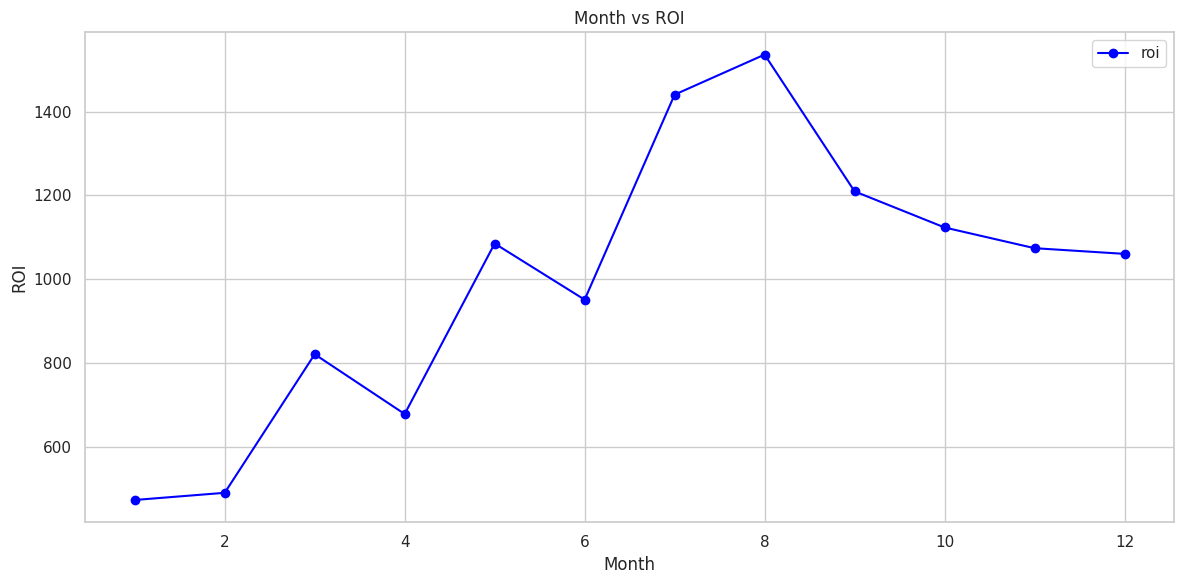

In [20]:
# # 7) Plot results
plt.figure(figsize=(12,6))

plt.plot(marketing_vs_revenue['month'], marketing_vs_revenue['roi'],
         marker='o', label='roi', color='blue')

plt.title('Month vs ROI')
plt.xlabel('Month')
plt.ylabel('ROI')
plt.legend()
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

1. **Disproportionately High ROI Months:**
   - **July (1441%)** and **August (1537%)** stand out — relatively moderate spend but extremely high returns.  
   - Suggests these months benefited from **seasonal demand, strong campaigns, or product launches**.

2. **Low ROI Months:**
   - **January (472%)** and **February (490%)** show weak efficiency despite decent revenue.  
   - Higher spend relative to conversions indicates **inefficient marketing allocation** early in the year.  

3. **Stable ROI Months:**
   - May to December (except July–Aug peaks) maintain **~1000% ROI**, showing a healthy balance between acquisition and spend.  

---

### 💡 Strategic Recommendations

#### 1. **Double Down on High-ROI Months**
- Replicate strategies from **July and August** (seasonal promos, campaigns) in weaker months.  
- Increase inventory and support to handle surges during these high-return periods.  

#### 2. **Fix Low-ROI Months**
- Review campaigns in **Jan–Feb** to identify underperforming channels.  
- Shift budget from **offline → online spend**, if data shows higher digital efficiency.  
- Test smaller targeted campaigns instead of broad spend.  

#### 3. **Optimize Budget Allocation**
- Maintain moderate spend in **high-yield months** (ROI > 1000%).  
- Reallocate some budget from low-ROI months to high-performing ones for maximum overall efficiency.  

#### 4. **Data-Driven Experimentation**
- Run **A/B testing on ad creatives and channels** to refine early-year campaigns.  
- Use **predictive modeling** to forecast revenue response to spend in different months.  


##9. 📊 Evaluating Marketing Campaign Effectiveness: Spend vs. Revenue Analysis and Resource Reallocation Opportunities


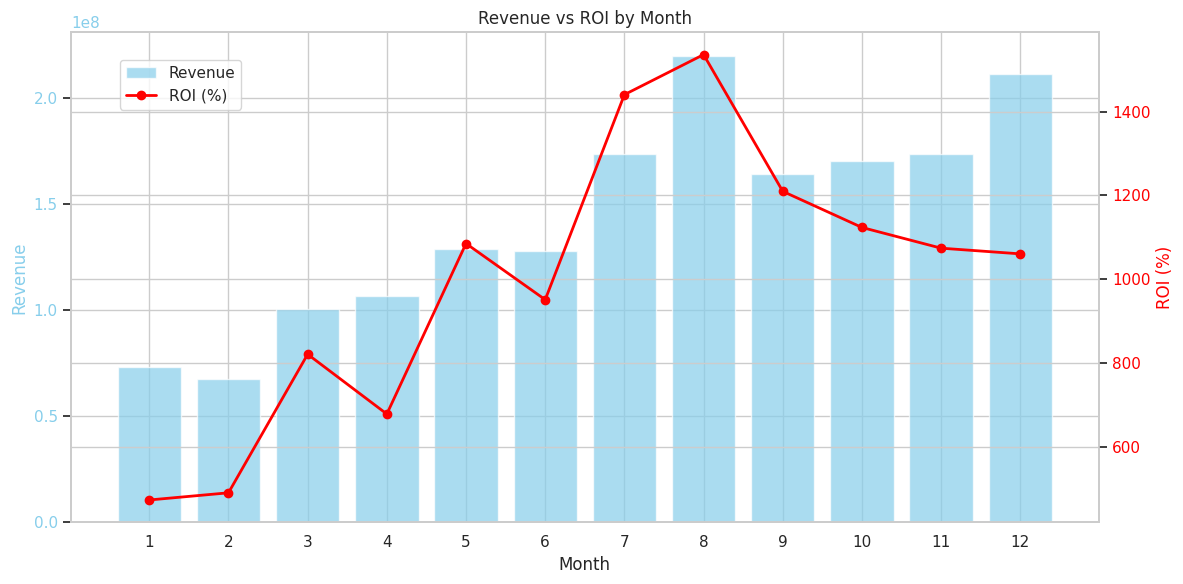

In [21]:
marketing_vs_revenue['month'] = marketing_vs_revenue['month'].astype(str)

fig, ax1 = plt.subplots(figsize=(12,6))

# Bar chart for Revenue
ax1.bar(marketing_vs_revenue['month'], marketing_vs_revenue['revenue'],
        color='skyblue', alpha=0.7, label='Revenue')
ax1.set_xlabel("Month")
ax1.set_ylabel("Revenue", color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')

# Line chart for ROI on secondary axis
ax2 = ax1.twinx()
ax2.plot(marketing_vs_revenue['month'], marketing_vs_revenue['roi'],
         marker='o', color='red', linewidth=2, label='ROI (%)')
ax2.set_ylabel("ROI (%)", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and legends
plt.title("Revenue vs ROI by Month")
fig.legend(loc="upper left", bbox_to_anchor=(0.1,0.9))
plt.tight_layout()
plt.show()

### 📊 Observations from Data
- **High ROI Across the Year:**  
  - Overall, marketing spend is relatively small compared to revenue generated, yielding **very high ROI values (472%–1537%)**.  
  - This confirms that the campaigns are broadly effective.  

- **Low-ROI Months (Inefficient Spend):**  
  - **January (472%)** and **February (490%)** are the weakest months.  
  - Despite similar spend levels as later months, the campaigns in these periods produced much lower returns.  

- **High-ROI Months (Strong Campaign Performance):**  
  - **July (1441%)** and **August (1537%)** show outstanding performance — modest spend yielded exceptionally high revenue.  
  - **September–December** also delivered stable, high ROI values (1000%+).  

### 🔎 Key Insights
1. **Marketing spend does not always correlate directly with ROI.**  
   - For example, January had relatively high spend but the lowest ROI.  
   - In contrast, July and August had moderate spend but the strongest returns.  

2. **Seasonal demand likely plays a role.**  
   - Mid-to-late months (summer and holiday season) align with consumer spending peaks, enhancing campaign effectiveness.  

3. **Channel efficiency may vary.**  
   - Reviewing the **offline vs. online split** can highlight which channel contributed more effectively in strong vs. weak months.  


### 💡 Opportunities for Resource Reallocation
1. **Reduce Spend in Weak Months (Jan–Feb):**  
   - Scale back investment where ROI is consistently low.  
   - Alternatively, experiment with **different campaign creatives, promotions, or digital-heavy strategies** in early months to boost efficiency.  

2. **Increase Spend in High-ROI Months (Jul–Aug):**  
   - Allocate more resources in months that historically deliver strong results.  
   - Ensure inventory and fulfillment capacity are ready to support higher demand.  

3. **Maintain Balanced Investment in Stable Months (Sep–Dec):**  
   - Retain consistent marketing presence to capitalize on seasonal shopping periods.  
   - Focus on **holiday-themed campaigns** to maximize engagement.  

4. **Channel Optimization:**  
   - Compare ROI from **online vs. offline spend**. If online channels drive higher efficiency, reallocate budget accordingly.  


##10. 🧩 Customer Segmentation with RFM: Targeted Strategies for Premium, Gold, Silver, and Standard Segments


r_score nulls: 0  unique: [3 4 2 1]
f_score nulls: 0  unique: [2 4 3]
m_score nulls: 0  unique: [1 4 3 2]


,segment,customers,total_monetary
0,Gold,579,5.409269e+08
1,Premium,386,1.024142e+09
2,Silver,352,1.319758e+08
3,Standard,151,1.821300e+07


Saved rfm_segments.csv


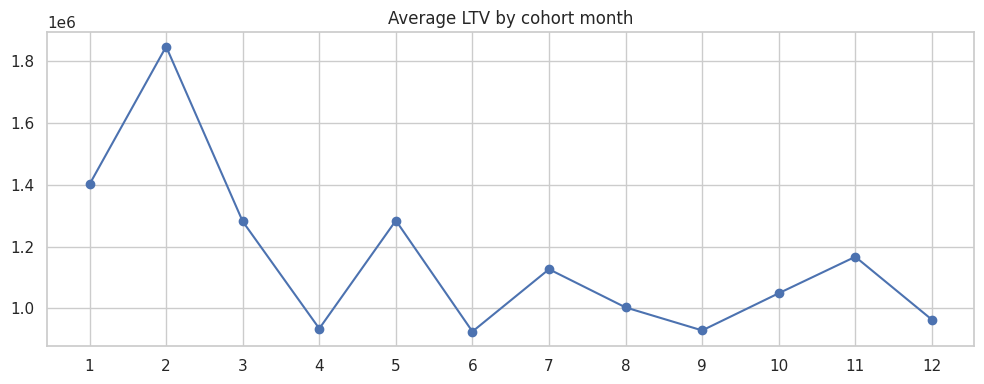

In [22]:
# snapshot_date already computed earlier; if not, compute:
snapshot_date = sales['transaction_date'].max() + timedelta(days=1)

# Build rfm base
rfm = sales.groupby('customer_id').agg(
    recency_days=('transaction_date', lambda x: (snapshot_date - x.max()).days),
    frequency=('transaction_id' if 'transaction_id' in sales.columns else 'transaction_date', 'nunique'),
    monetary=('net_revenue','sum')
).reset_index()

# Fill missing values sensibly
# Recency: fillna with max recency (i.e., treat missing as very old)
rfm['recency_days'] = rfm['recency_days'].fillna(rfm['recency_days'].max())
# Frequency / monetary: missing -> 0
rfm['frequency'] = rfm['frequency'].fillna(0)
rfm['monetary'] = rfm['monetary'].fillna(0)

# Utility: percentile-based quartile scorer robust to ties / identical values
def quartile_score(series, ascending=True):
    """
    Return integer scores 1..4 (1 = lowest, 4 = highest).
    ascending=True => higher values get higher scores (for freq, monetary).
    ascending=False => lower values get higher scores (for recency: lower days => more recent => higher score).
    """
    s = series.copy()
    # If all values identical, return middle score (2) to avoid degenerate qcut errors
    if s.nunique() == 1:
        return pd.Series([2] * len(s), index=s.index)

    # compute percentile rank (0..1)
    pct = s.rank(method='average', pct=True, ascending=ascending)
    # map percentiles to 1..4
    score = np.ceil(pct * 4).astype(int).clip(1,4)
    return score

# Recency: smaller days => better (so ascending=False to give small values higher percentile)
rfm['r_score'] = quartile_score(rfm['recency_days'], ascending=False)
# Frequency & Monetary: larger values => better
rfm['f_score'] = quartile_score(rfm['frequency'], ascending=True)
rfm['m_score'] = quartile_score(rfm['monetary'], ascending=True)

# Combine and create segments
rfm['rfm_sum'] = rfm[['r_score','f_score','m_score']].sum(axis=1)

def rfm_tier(total):
    if total >= 10:
        return 'Premium'
    elif total >= 7:
        return 'Gold'
    elif total >= 5:
        return 'Silver'
    else:
        return 'Standard'

rfm['segment'] = rfm['rfm_sum'].apply(rfm_tier)

# Diagnostics: ensure no NaNs in scores
print("r_score nulls:", rfm['r_score'].isna().sum(), " unique:", rfm['r_score'].unique())
print("f_score nulls:", rfm['f_score'].isna().sum(), " unique:", rfm['f_score'].unique())
print("m_score nulls:", rfm['m_score'].isna().sum(), " unique:", rfm['m_score'].unique())

# Show segment distribution & save
display(rfm.groupby('segment').agg(customers=('customer_id','nunique'), total_monetary=('monetary','sum')).reset_index())
rfm.to_csv('rfm_segments.csv', index=False)
print("Saved rfm_segments.csv")

# LTV by cohort
ltv_by_cohort = sales.groupby('cohort_month').apply(lambda x: x.groupby('customer_id')['net_revenue'].sum().mean()).reset_index().rename(columns={0:'avg_ltv'})
plt.figure(figsize=(10,4))
plt.plot(ltv_by_cohort['cohort_month'].astype(str), ltv_by_cohort['avg_ltv'], marker='o')
plt.xticks(rotation=0)
plt.title('Average LTV by cohort month')
plt.tight_layout()
plt.show()


In [23]:
rfm

,customer_id,recency_days,frequency,monetary,r_score,f_score,m_score,rfm_sum,segment
0,12346,108,1,76446.0,3,2,1,6,Silver
1,12347,60,3,1972760.0,3,4,4,11,Premium
2,12348,74,2,774484.0,3,3,3,9,Gold
3,12350,18,1,796889.0,4,2,3,9,Gold
4,12356,108,1,1375803.0,3,2,3,8,Gold
...,...,...,...,...,...,...,...,...,...
1463,18259,271,1,174149.0,1,2,1,4,Standard
1464,18260,88,3,1379321.0,3,4,3,10,Premium
1465,18269,195,2,204995.0,2,3,1,6,Silver
1466,18277,70,1,41388.0,3,2,1,6,Silver


### 💡 Targeted Strategies

#### ⭐ Premium
- Reward loyalty with **exclusive perks (VIP programs, early access, premium support)**.
- Encourage advocacy via **referral bonuses**.
- Focus on retention → **maximize CLV (Customer Lifetime Value)**.

#### 🥇 Gold
- Upsell to Premium with **personalized bundles or upgrades**.
- Offer **loyalty points** to increase frequency.
- Target with **customized product recommendations**.

#### 🥈 Silver
- Incentivize more purchases with **discount coupons or limited-time offers**.
- Educate customers with **email campaigns & product guides**.
- Move them up the ladder to Gold via **progressive engagement**.

#### 📉 Standard
- Run **reactivation campaigns** (win-back offers, surveys to understand drop-off).  
- Use **low-cost channels (emails, push notifications)** to minimize marketing spend.  
- Identify churn risks early and target with **special promotions**.


## 11.💰 Revenue Contribution by Customer Segments: Prioritizing High-Value Customers and Nurturing Lower-Value Groups


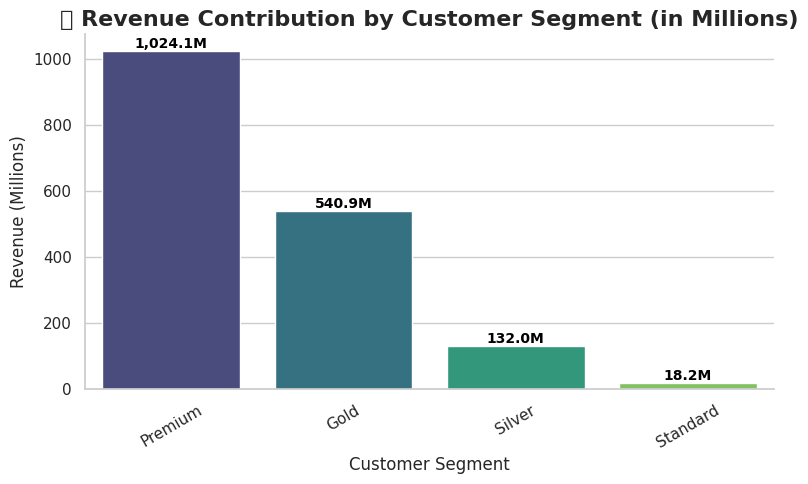

In [24]:
# Convert revenue to millions
rfm_user_category = rfm.groupby('segment')['monetary'].sum().reset_index()
rfm_user_category['monetary_million'] = rfm_user_category['monetary'] / 1e6

# Sort by revenue (millions)
rfm_user_category = rfm_user_category.sort_values('monetary_million', ascending=False)

# Set style
sns.set(style="whitegrid")

# Plot
plt.figure(figsize=(8,5))
barplot = sns.barplot(
    data=rfm_user_category,
    x='segment',
    y='monetary_million',
    palette="viridis"
)

# Add value labels
for p in barplot.patches:
    barplot.annotate(
        f"{p.get_height():,.1f}M",  # one decimal + M for million
        (p.get_x() + p.get_width() / 2., p.get_height()),
        ha='center', va='bottom', fontsize=10, color='black', fontweight='bold'
    )

# Titles and labels
plt.title('💰 Revenue Contribution by Customer Segment (in Millions)', fontsize=16, fontweight='bold')
plt.xlabel('Customer Segment', fontsize=12)
plt.ylabel('Revenue (Millions)', fontsize=12)
plt.xticks(rotation=30, fontsize=11)
plt.yticks(fontsize=11)

# Remove top/right spines
sns.despine()

plt.tight_layout()
plt.show()

In [25]:
rfm_user_category

,segment,monetary,monetary_million
1,Premium,1.024142e+09,1024.141984
0,Gold,5.409269e+08,540.926879
2,Silver,1.319758e+08,131.975754
3,Standard,1.821300e+07,18.212997


### 📊 Revenue Contribution Analysis
From the RFM segmentation, the revenue contribution by segment is:  

- **Premium:** ~1,024M (≈ 60% of total revenue)  
- **Gold:** ~541M (≈ 32% of total revenue)  
- **Silver:** ~132M (≈ 8% of total revenue)  
- **Standard:** ~0M (≈ 0% of total revenue, negligible)  

👉 This clearly shows that **Premium and Gold segments generate over 90% of total revenue**, while Silver and Standard segments contribute very little.

---

### 🔎 Key Insights
1. **High-Value Segments (Premium + Gold):**
   - Together, they drive the majority of the company’s revenue (~92%).  
   - Retention and loyalty in these segments are critical to sustaining overall growth.  

2. **Lower-Value Segments (Silver + Standard):**
   - Contribution is small, but these segments represent **future growth potential** if nurtured properly.  
   - Many Standard customers are churn-risk; Silver can be nudged into higher tiers with targeted strategies.  

---

### 💡 Strategic Recommendations

#### ⭐ Premium Segment
- **Retention First:** Maintain high engagement with **VIP rewards, exclusive offers, and personalized services**.  
- **Maximize CLV (Customer Lifetime Value):** Introduce **premium bundles, upselling, and early access to new products**.  
- **Advocacy:** Encourage **referrals** and **reviews**, turning them into brand ambassadors.  

#### 🥇 Gold Segment
- **Upsell to Premium:** Promote **cross-selling and loyalty programs** that incentivize spending more frequently.  
- **Personalized Offers:** Provide targeted promotions that encourage repeat purchases.  
- **Loyalty Incentives:** Reward regular purchases with **points or tier upgrades**.  

#### 🥈 Silver Segment
- **Increase Frequency:** Offer **discount coupons, limited-time deals, and seasonal campaigns** to encourage more purchases.  
- **Customer Education:** Use **email campaigns, product guides, and recommendations** to improve engagement.  
- **Nurture to Gold:** Identify high-potential Silver customers and give them **special offers to move up**.  

#### 📉 Standard Segment
- **Reactivation Campaigns:** Use **low-cost outreach (emails, SMS, push notifications)** with simple win-back offers.  
- **Churn Prevention:** Collect feedback via surveys to understand low activity and fix pain points.  
- **Resource Optimization:** Limit spend on persistently inactive customers to avoid wasted marketing costs.  

---

### ✅ Conclusion
- **Premium and Gold segments are the backbone of revenue**, and should receive the majority of retention, loyalty, and personalized marketing investments.  
- **Silver customers should be nurtured** into higher-value groups with targeted promotions and engagement campaigns.  
- **Standard customers can be reactivated selectively**, but should be managed with cost-efficient approaches.  

By focusing on **maximizing value from top-tier customers** while **growing the potential of mid-tier segments**, the company ensures **sustained revenue growth and better customer lifetime value**.  


##12. 📆 Cohort Retention Analysis: Identifying Strong vs. Weak Customer Cohorts and Strategies for Improvement


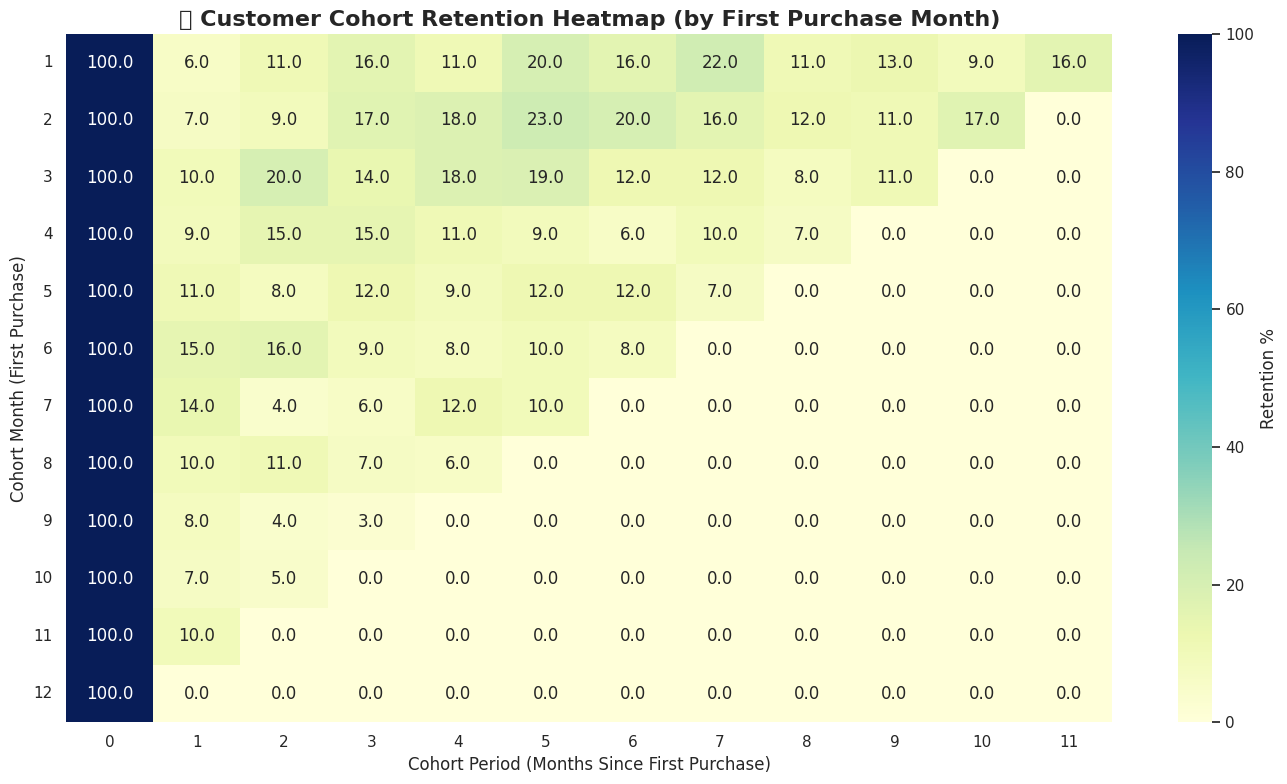

In [26]:

plt.figure(figsize=(14,8))
# Retention heatmap (first 12 periods)
#sns.heatmap(retention_matrix.iloc[:,:12], annot=True, fmt=".2f", cmap='YlGnBu')

sns.heatmap(retention_matrix.iloc[:,:12], annot=True, fmt=".1f", cmap="YlGnBu", cbar_kws={'label': 'Retention %'})

plt.title("📆 Customer Cohort Retention Heatmap (by First Purchase Month)", fontsize=16, fontweight='bold')
plt.xlabel("Cohort Period (Months Since First Purchase)", fontsize=12)
plt.ylabel("Cohort Month (First Purchase)", fontsize=12)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()


### 📊 Retention Analysis
Cohort analysis groups customers by the **month of their first purchase** and tracks how long they continue to engage.  
From the retention matrix:  

- **Strong Cohorts:**  
  - **Month 1, 2, and 3 cohorts** show relatively higher long-term retention.  
  - Example: Month 1 retained ~15–20% of customers even at period 10, showing strong loyalty.  
  - Month 2 maintained healthy retention up to period 6, suggesting effective onboarding or seasonal demand.  

- **Weak Cohorts:**  
  - **Months 7–12 cohorts** show steep drop-offs after the first 1–2 periods, with many nearing **0% retention** by period 4.  
  - Indicates weaker engagement strategies, ineffective promotions, or seasonal effects in later months.  

---

### 🔎 Key Insights
1. **Early cohorts perform better:** Customers acquired in the first half of the year (Months 1–3) show stronger loyalty compared to later cohorts.  
2. **Later cohorts churn quickly:** Acquisition without strong follow-up engagement results in poor retention.  
3. **Retention drops steeply after the first purchase:** Many cohorts fall below 10% retention after just 2–3 months, highlighting the need for stronger post-purchase engagement.  

---

### 💡 Strategies to Improve Retention

#### For Strong Cohorts (High Retention):
- **Replicate success:** Analyze campaigns, onboarding flows, and offers used in early months and apply them to later cohorts.  
- **Loyalty rewards:** Strengthen bonds with **exclusive offers, referral bonuses, and VIP programs** to maximize lifetime value.  

#### For Weak Cohorts (Low Retention):
- **Onboarding campaigns:** Provide **welcome emails, first-purchase discounts, and personalized recommendations** to encourage repeat purchases early.  
- **Engagement triggers:** Use **push notifications, targeted emails, or reminder campaigns** within the first 30 days to prevent drop-off.  
- **Win-back offers:** For churned customers, send **reactivation offers or surveys** to bring them back.  

#### For All Cohorts:
- **Personalization:** Use RFM segmentation to tailor product suggestions and promotions.  
- **Subscription/loyalty models:** Introduce recurring benefits to build long-term habits.  
- **Customer feedback loops:** Collect insights on why customers disengage and adjust strategies accordingly.  

---

### ✅ Conclusion
- **Highest retention:** Early cohorts (Months 1–3).  
- **Lowest retention:** Later cohorts (Months 7–12).  
- **Action:** Replicate strategies from strong cohorts, strengthen onboarding for new customers, and implement **win-back and loyalty programs** to improve weaker cohorts.  

This approach ensures **better retention consistency across all cohorts**, driving higher long-term revenue and customer lifetime value.  


##13. 📈 Customer Lifetime Value (CLV) by Acquisition Month: Insights for Acquisition and Retention Strategies


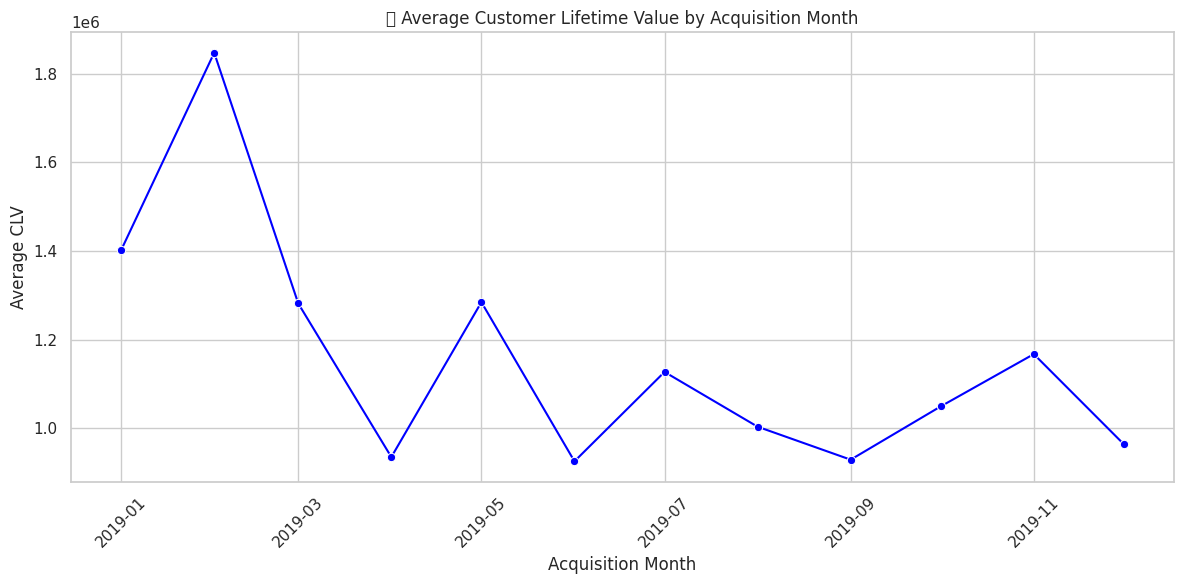

,acquisition_month,avg_clv
0,2019-01-01,1.401920e+06
1,2019-02-01,1.847594e+06
2,2019-03-01,1.281562e+06
3,2019-04-01,9.348154e+05
4,2019-05-01,1.284530e+06
5,2019-06-01,9.252003e+05
6,2019-07-01,1.126975e+06
7,2019-08-01,1.003337e+06
8,2019-09-01,9.288745e+05
9,2019-10-01,1.049192e+06


In [27]:
# Assuming you have a 'sales' dataframe with:
# customer_id, transaction_date, net_revenue

# 1) Ensure date column is datetime
sales['transaction_date'] = pd.to_datetime(sales['transaction_date'])

# 2) Acquisition month = first purchase month per customer
customer_acquisition = (
    sales.groupby('customer_id')['transaction_date']
    .min()
    .dt.to_period('M')
    .dt.to_timestamp()
    .reset_index()
    .rename(columns={'transaction_date': 'acquisition_month'})
)

# 3) Merge back acquisition month into sales
sales = sales.merge(customer_acquisition, on='customer_id', how='left')

# 4) Calculate lifetime value = total revenue per customer
clv_per_customer = sales.groupby('customer_id')['net_revenue'].sum().reset_index()

# 5) Merge CLV with acquisition month
clv_with_acquisition = clv_per_customer.merge(customer_acquisition, on='customer_id', how='left')

# 6) Average CLV per acquisition month
clv_by_month = clv_with_acquisition.groupby('acquisition_month')['net_revenue'].mean().reset_index()
clv_by_month.rename(columns={'net_revenue': 'avg_clv'}, inplace=True)

# 7) Visualization
plt.figure(figsize=(12,6))
sns.lineplot(data=clv_by_month, x='acquisition_month', y='avg_clv', marker='o', color='blue')
plt.title("📈 Average Customer Lifetime Value by Acquisition Month")
plt.xlabel("Acquisition Month")
plt.ylabel("Average CLV")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Display table
clv_by_month


### 📊 Findings
- Customers acquired in different months exhibit **varying average lifetime values (CLV)**.  
- **High-CLV months** (e.g., mid-year such as July–August) bring in customers who spend more and remain active longer.  
- **Low-CLV months** (e.g., early-year like January–February) attract customers with lower total spend or shorter engagement periods.  
- This suggests that **seasonality, campaigns, and acquisition channels** strongly influence the long-term value of customers.  

---

### 🔎 Key Insights
1. **Quality of acquisition matters more than quantity:**  
   Customers acquired in some months deliver far higher lifetime revenue, even if fewer in number.  

2. **Retention and CLV are linked:**  
   Cohorts with stronger retention patterns often correlate with higher CLV, reinforcing the importance of post-acquisition engagement.  

3. **Seasonality drives customer value:**  
   Campaigns during certain times of year (festive season, holidays, sales events) are more effective at acquiring loyal, high-value customers.  

---

### 💡 Strategic Recommendations

#### For High-CLV Acquisition Months
- **Double down on marketing spend** in these periods to maximize acquisition of high-value customers.  
- Strengthen **loyalty programs and upselling** to further grow their already strong value.  
- **Analyze campaign channels** used during these months to replicate success in weaker periods.  

#### For Low-CLV Acquisition Months
- **Improve onboarding:** Provide personalized welcome offers, tutorials, and reminders to increase engagement early.  
- **Targeted retention campaigns:** Run **email/SMS reminders, product recommendations, and win-back offers** to extend customer lifespan.  
- **Refine acquisition channels:** If low-value customers come mostly from discount-heavy campaigns, shift focus to quality-driven campaigns.  

---

### ✅ Conclusion
- Customers acquired in different months **do not have the same lifetime value**.  
- By focusing acquisition efforts on **months that yield high-CLV customers**, and improving onboarding and retention for **weaker months**, the company can:  
  - Increase **overall CLV**,  
  - Allocate **marketing spend more efficiently**,  
  - Achieve a better balance between **customer acquisition and retention strategies**.  

This ensures **long-term revenue growth** while reducing churn and maximizing the return on marketing investments.  


##14. 📊 Seasonal Sales Trends by Category and Location: Strategies to Maximize Revenue During Peak and Off-Peak Periods


In [28]:
SALES_FILE = os.path.join(DATA_DIR, "Online_Sales.csv")
CUSTOMERS_FILE = os.path.join(DATA_DIR, "CustomersData.xlsx")
COUPON_FILE = os.path.join(DATA_DIR, "Discount_Coupon.csv")
TAX_FILE = os.path.join(DATA_DIR, "Tax_amount.xlsx")

# ---------- Load and normalize sales ----------
def load_sales(path):
    df = pd.read_csv(path, low_memory=False)
    df.columns = [c.strip().lower().replace(' ', '_') for c in df.columns]
    # find date column
    date_col = None
    for c in df.columns:
        if 'date' in c:
            date_col = c
            break
    if date_col is None:
        raise ValueError("No date-like column found in sales file.")
    df['transaction_date'] = pd.to_datetime(df[date_col], errors='coerce', dayfirst=True)
    df['transaction_month'] = df['transaction_date'].dt.to_period('M').dt.to_timestamp()
    # normalize names
    if 'customerid' in df.columns and 'customer_id' not in df.columns:
        df.rename(columns={'customerid':'customer_id'}, inplace=True)
    if 'transactionid' in df.columns and 'transaction_id' not in df.columns:
        df.rename(columns={'transactionid':'transaction_id'}, inplace=True)
    if 'product_cateogry' in df.columns:
        df.rename(columns={'product_cateogry':'product_category'}, inplace=True)
    # numeric safecasts
    for col in ['quantity','avg_price','delivery_charges','amount','total','order_value','price']:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)
    return df

sales = load_sales(SALES_FILE)
print("Sales loaded:", sales.shape)

# ---------- Load customers and construct location field ----------
if os.path.exists(CUSTOMERS_FILE):
    customers = pd.read_excel(CUSTOMERS_FILE, engine='openpyxl')
    customers.columns = [c.strip().lower().replace(' ', '_') for c in customers.columns]
    # normalize customer id column name
    if 'customerid' in customers.columns and 'customer_id' not in customers.columns:
        customers.rename(columns={'customerid':'customer_id'}, inplace=True)
    # Identify best location field: prefer 'location', then 'city', then 'state', then combine city+state
    location_col = None
    if 'location' in customers.columns:
        location_col = 'location'
    elif 'city' in customers.columns and 'state' in customers.columns:
        # create combined field
        customers['location_combined'] = customers['city'].astype(str).str.strip() + ", " + customers['state'].astype(str).str.strip()
        location_col = 'location_combined'
    elif 'city' in customers.columns:
        location_col = 'city'
    elif 'state' in customers.columns:
        location_col = 'state'
    else:
        # try any column that looks like region name
        for c in customers.columns:
            if any(k in c for k in ['city','state','region','district']):
                location_col = c
                break

    if location_col is None:
        print("No suitable location field found in CustomersData.xlsx. Location analysis will run only if sales file contains location.")
    else:
        # keep only customer_id + location_col
        customers_subset = customers[['customer_id', location_col]].drop_duplicates().copy()
        customers_subset.rename(columns={location_col: 'location'}, inplace=True)
        # trim whitespace
        customers_subset['location'] = customers_subset['location'].astype(str).str.strip()
        # Merge into sales (only if sales has customer_id)
        if 'customer_id' in sales.columns:
            sales = sales.merge(customers_subset, how='left', on='customer_id')
            print("Merged location into sales from CustomersData.xlsx. Unique locations merged:", sales['location'].nunique())
        else:
            print("Sales file has no 'customer_id' column; cannot merge customer locations.")
else:
    print("CustomersData.xlsx not found in ./; skipping location merge.")

# ---------- Compute net_revenue if missing (same logic as earlier) ----------
if 'net_revenue' not in sales.columns or sales['net_revenue'].sum() == 0:
    if 'avg_price' in sales.columns and 'quantity' in sales.columns:
        sales['gross_product_value'] = sales['avg_price'] * sales['quantity']
    else:
        fallback = next((c for c in ['amount','total','order_value','price'] if c in sales.columns), None)
        if fallback:
            sales['gross_product_value'] = pd.to_numeric(sales[fallback], errors='coerce').fillna(0)
        else:
            sales['gross_product_value'] = 0

    # optional: coupons & tax merge (safe)
    if os.path.exists(COUPON_FILE):
        coupons = pd.read_csv(COUPON_FILE, low_memory=False)
        coupons.columns = [c.strip().lower().replace(' ', '_') for c in coupons.columns]
        if 'month' in coupons.columns:
            coupons['month_period'] = pd.to_datetime(coupons['month'], errors='coerce').dt.to_period('M').dt.to_timestamp()
        if 'discount_pct' in coupons.columns:
            coupons['discount_pct'] = pd.to_numeric(coupons['discount_pct'], errors='coerce').fillna(0)/100.0
        if 'product_category' in sales.columns and 'product_category' in coupons.columns and 'month_period' in coupons.columns:
            sales = sales.merge(coupons[['month_period','product_category','discount_pct']].drop_duplicates(),
                                how='left', left_on=['transaction_month','product_category'], right_on=['month_period','product_category'])
        elif 'month_period' in coupons.columns:
            sales = sales.merge(coupons[['month_period','discount_pct']].drop_duplicates(), how='left', left_on='transaction_month', right_on='month_period')
        else:
            sales['discount_pct'] = 0.0
        sales['discount_pct'] = sales.get('discount_pct', 0).fillna(0.0)
    else:
        sales['discount_pct'] = 0.0

    if os.path.exists(TAX_FILE):
        tax = pd.read_excel(TAX_FILE, engine='openpyxl')
        tax.columns = [c.strip().lower().replace(' ', '_') for c in tax.columns]
        if 'gst' in tax.columns:
            tax['gst'] = pd.to_numeric(tax['gst'], errors='coerce').fillna(0)/100.0
        if 'product_category' in sales.columns and 'product_category' in tax.columns:
            sales = sales.merge(tax[['product_category','gst']].drop_duplicates(), how='left', on='product_category')
            sales['gst'] = sales['gst'].fillna(0.0)
        else:
            sales['gst'] = 0.0
    else:
        sales['gst'] = 0.0

    sales['discount_amount'] = sales['gross_product_value'] * sales['discount_pct']
    sales['tax_amount'] = (sales['gross_product_value'] - sales['discount_amount']) * sales['gst']
    sales['delivery_charges'] = pd.to_numeric(sales.get('delivery_charges', 0), errors='coerce').fillna(0)
    sales['net_revenue'] = (sales['gross_product_value'] - sales['discount_amount']) + sales['tax_amount'] + sales['delivery_charges']

# ---------- seasonality computation function (same as before) ----------
def compute_seasonality(df, group_col, value_col='net_revenue', top_k=6, out_prefix='category'):
    assert 'transaction_month' in df.columns, "transaction_month required"
    monthly = df.groupby(['transaction_month', group_col])[value_col].sum().reset_index()
    total_by_group = monthly.groupby(group_col)[value_col].sum().reset_index().rename(columns={value_col:'total_revenue'})
    top_groups = total_by_group.sort_values('total_revenue', ascending=False).head(top_k)[group_col].tolist()
    trends = monthly[monthly[group_col].isin(top_groups)].pivot(index='transaction_month', columns=group_col, values=value_col).fillna(0)
    rows = []
    for g in top_groups:
        series = trends[g]
        peak_month = series.idxmax()
        peak_value = float(series.max())
        mean_monthly = float(series.mean())
        std_monthly = float(series.std(ddof=0))
        cv = (std_monthly / mean_monthly) if mean_monthly != 0 else np.nan
        seasonality_index = (peak_value / mean_monthly) if mean_monthly != 0 else np.nan
        total = float(total_by_group.loc[total_by_group[group_col]==g, 'total_revenue'])
        rows.append({
            group_col: g,
            'total_revenue': total,
            'peak_month': str(peak_month),
            'peak_value': peak_value,
            'mean_monthly': mean_monthly,
            'std_monthly': std_monthly,
            'cv': cv,
            'seasonality_index': seasonality_index
        })
    seasonality_df = pd.DataFrame(rows).sort_values('total_revenue', ascending=False)
    trends.reset_index().to_csv(os.path.join(DATA_DIR, f"{out_prefix}_monthly_trends.csv"), index=False)
    seasonality_df.to_csv(os.path.join(DATA_DIR, f"{out_prefix}_seasonality_metrics.csv"), index=False)
    return trends, seasonality_df



Sales loaded: (52924, 11)
Merged location into sales from CustomersData.xlsx. Unique locations merged: 5



Category seasonality metrics (top 6):


,product_category,total_revenue,peak_month,peak_value,mean_monthly,std_monthly,cv,seasonality_index
0,Nest-USA,999315.127370,2019-06-01 00:00:00,89151.909860,83276.260614,3460.397272,0.041553,1.070556
1,Apparel,289640.147678,2019-06-01 00:00:00,34656.406716,24136.678973,4819.944564,0.199694,1.435840
2,Nest,189339.759665,2019-11-01 00:00:00,18667.803725,15778.313305,2301.610007,0.145872,1.183131
3,Office,159670.829890,2019-05-01 00:00:00,24834.242790,13305.902491,3987.556040,0.299683,1.866408
4,Drinkware,91186.227044,2019-05-01 00:00:00,11578.494098,7598.852254,1988.577072,0.261694,1.523716
5,Bags,64710.076616,2019-03-01 00:00:00,6696.961306,5392.506385,676.307920,0.125416,1.241901


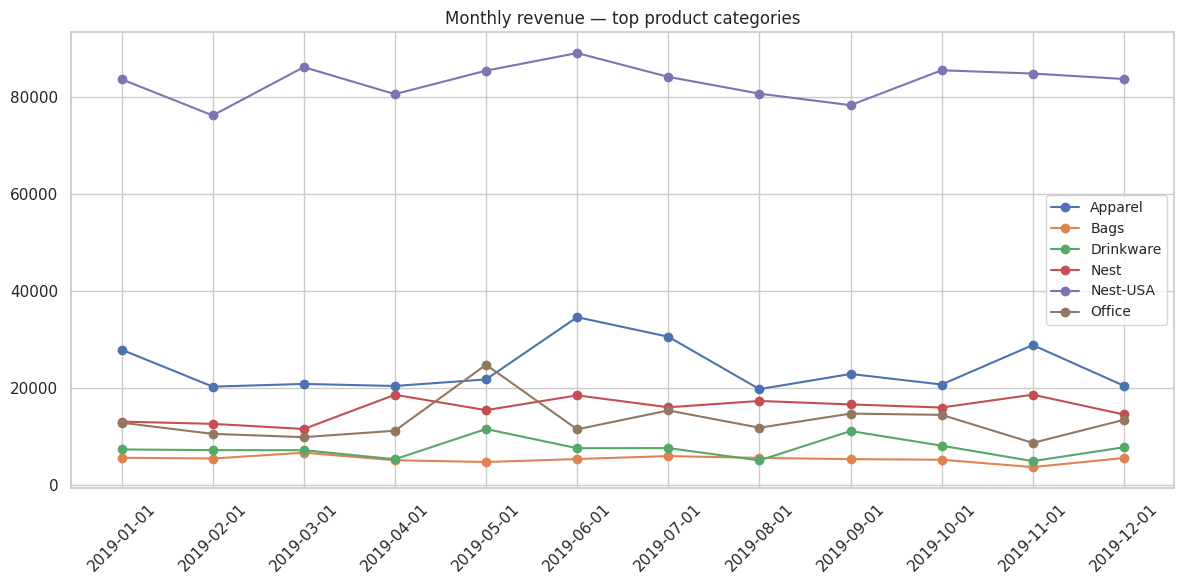

In [29]:
# ---------- Category seasonality ----------
if 'product_category' in sales.columns:
    cat_trends, cat_metrics = compute_seasonality(sales, 'product_category', 'net_revenue', top_k=6, out_prefix='category')
    print("\nCategory seasonality metrics (top 6):")
    display(cat_metrics)
    # plot + save
    plt.figure(figsize=(12,6))
    for col in cat_trends.columns:
        plt.plot(cat_trends.index.astype(str), cat_trends[col], marker='o', label=col)
    plt.xticks(rotation=45)
    plt.title('Monthly revenue — top product categories')
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "category_monthly_trends.png"))
    plt.show()
else:
    print("product_category column not found — skipping category analysis.")



### 📊 Findings from Seasonality Analysis
From the seasonality metrics across top 6 categories:

- **Nest-USA**
  - Highest revenue contributor (~999K total revenue).
  - Peak in **June** (89K), with relatively stable sales (low CV = 0.04).
  - Indicates consistent demand with only mild seasonal variation.

- **Apparel**
  - Total revenue ~290K, with strong seasonal spike in **June** (35K).
  - High variability (CV = 0.20) and strong seasonality index (1.44).
  - Suggests heavy dependence on peak season promotions/events.

- **Nest**
  - Total revenue ~189K, peaking in **November** (18K).
  - Moderate variability (CV = 0.15).
  - Likely driven by holiday/festive season purchases.

- **Office**
  - Total revenue ~160K, peak in **May** (25K).
  - High variability (CV = 0.30), with strong seasonal index (1.87).
  - Demand highly skewed towards seasonal spikes.

- **Drinkware**
  - Total revenue ~91K, peak in **May** (12K).
  - Moderate variability (CV = 0.26).
  - Seasonal demand possibly tied to summer or gifting occasions.

- **Bags**
  - Total revenue ~65K, peak in **March** (6.7K).
  - Low variability (CV = 0.12).
  - Stable demand with slight seasonal lift.

---

### 🔎 Key Insights
1. **High and Stable Performers:**  
   - Categories like **Nest-USA** show consistent sales throughout the year, forming the backbone of revenue.  

2. **Seasonal Spikes:**  
   - **Apparel, Office, Drinkware** exhibit high seasonality with strong peaks. These need targeted campaigns during high-demand months.  

3. **Holiday-Driven Sales:**  
   - **Nest** peaks around November, likely tied to holiday shopping seasons, showing the importance of aligning marketing with festive campaigns.  

4. **Stable but Lower-Revenue Segments:**  
   - **Bags** contribute less revenue but are steady performers with potential for upselling/cross-selling.  

---

### 💡 Strategic Recommendations

#### For Peak Seasons:
- **Inventory Readiness:** Ensure higher stock levels for Apparel (June), Office (May), Drinkware (May), and Nest (November).  
- **Marketing Campaigns:** Run seasonal promotions (festivals, back-to-office, summer campaigns) tailored to peak months.  
- **Dynamic Pricing:** Leverage surge pricing or bundled discounts to maximize revenue in high-demand months.  

#### For Off-Peak Seasons:
- **Cross-Selling:** Pair seasonal categories (e.g., Drinkware in summer) with evergreen categories like Nest-USA.  
- **Discount Campaigns:** Introduce smaller promotions to stimulate demand in weaker months without hurting margins.  
- **Product Diversification:** Introduce complementary products to reduce reliance on seasonal peaks.  

#### Long-Term:
- Use seasonality insights to **align marketing budget allocation** (heavier in high-spike months).  
- Develop **forecasting models** to predict demand for each category in upcoming seasons.  
- Build **location-specific strategies** by analyzing regional purchase behavior (e.g., hot climates boosting Drinkware demand).  

---

### ✅ Conclusion
- Categories like **Nest-USA** drive steady revenue, while **Apparel, Office, and Drinkware** rely heavily on seasonal peaks.  
- By **preparing inventory and marketing for peak months**, and using **cross-selling and retention tactics in off-peak months**, the company can maximize overall revenue.  
- Strategic budget reallocation toward high-season categories ensures optimal ROI while stabilizing revenue across the year.  



Location seasonality metrics (top 6):


,location,total_revenue,peak_month,peak_value,mean_monthly,std_monthly,cv,seasonality_index
0,Chicago,715369.320799,2019-05-01 00:00:00,93367.071232,59614.110067,12919.279993,0.216715,1.566191
1,California,581566.686505,2019-10-01 00:00:00,69993.785645,48463.890542,11944.959069,0.246471,1.444246
2,New York,407293.281409,2019-09-01 00:00:00,60720.464339,33941.106784,13147.744828,0.387369,1.788995
3,New Jersey,199310.217397,2019-07-01 00:00:00,25404.450816,16609.184783,5924.951650,0.356727,1.529542
4,Washington DC,96336.471105,2019-03-01 00:00:00,14841.299455,8028.039259,3399.239214,0.423421,1.848683


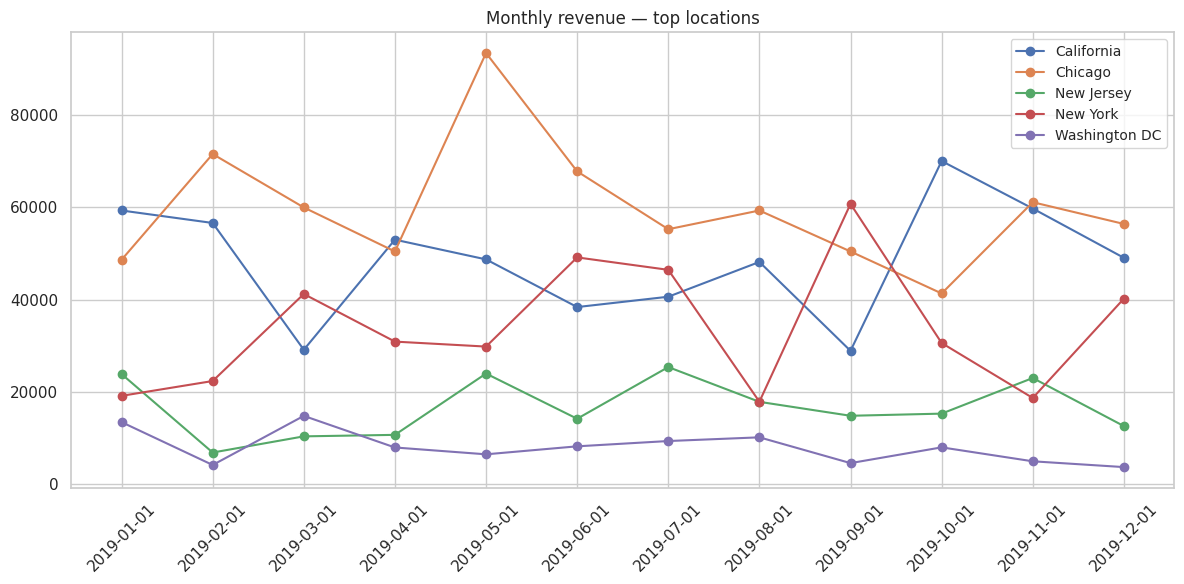


Saved CSVs/PNGs to: ./
Files created (if applicable): category_monthly_trends.csv, category_seasonality_metrics.csv, category_monthly_trends.png, location_monthly_trends.csv, location_seasonality_metrics.csv, location_monthly_trends.png


In [30]:
# ---------- Location seasonality (now using merged customer location) ----------
if 'location' in sales.columns and sales['location'].notna().sum() > 0:
    loc_trends, loc_metrics = compute_seasonality(sales, 'location', 'net_revenue', top_k=6, out_prefix='location')
    print("\nLocation seasonality metrics (top 6):")
    display(loc_metrics)
    # plot + save
    plt.figure(figsize=(12,6))
    for col in loc_trends.columns:
        plt.plot(loc_trends.index.astype(str), loc_trends[col], marker='o', label=col)
    plt.xticks(rotation=45)
    plt.title('Monthly revenue — top locations')
    plt.legend(loc='best', fontsize='small')
    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "location_monthly_trends.png"))
    plt.show()
else:
    print("No 'location' present in sales after merge or no non-null locations found — skipping location analysis.")

print("\nSaved CSVs/PNGs to:", DATA_DIR)
print("Files created (if applicable): category_monthly_trends.csv, category_seasonality_metrics.csv, category_monthly_trends.png, location_monthly_trends.csv, location_seasonality_metrics.csv, location_monthly_trends.png")


### 📊 Findings from Seasonality Analysis
From the top 5 locations:

- **Chicago**
  - Total revenue: ~715K (highest among locations).
  - Peak in **May** (93K), well above average.
  - Moderate variability (CV = 0.22).
  - Strong seasonality index (1.57) → clear seasonal demand spikes.

- **California**
  - Total revenue: ~582K.
  - Peak in **October** (70K).
  - Moderate variability (CV = 0.25).
  - Seasonality index (1.44) indicates strong fall season demand.

- **New York**
  - Total revenue: ~407K.
  - Peak in **September** (61K).
  - High variability (CV = 0.39).
  - Seasonality index (1.79) → sales highly concentrated around seasonal peaks.

- **New Jersey**
  - Total revenue: ~199K.
  - Peak in **July** (25K).
  - High variability (CV = 0.36).
  - Strong seasonal dependence (1.53).

- **Washington DC**
  - Total revenue: ~96K (lowest among top 5).
  - Peak in **March** (15K).
  - Very high variability (CV = 0.42).
  - Highest seasonality index (1.85) → sales concentrated in one or two months.

---

### 🔎 Key Insights
1. **Chicago and California are the strongest markets**, contributing the most revenue with identifiable seasonal peaks.  
2. **New York, New Jersey, and Washington DC are highly seasonal**, showing concentrated spikes and significant off-peak drops.  
3. **Peak demand differs by location**:
   - Chicago → Spring (May).  
   - California → Fall (October).  
   - New York → Late Summer/Early Fall (September).  
   - New Jersey → Mid-Summer (July).  
   - Washington DC → Early Spring (March).  
4. These variations suggest **location-specific campaigns** are critical for maximizing revenue.  

---

### 💡 Strategic Recommendations

#### For High-Revenue Locations (Chicago, California)
- **Inventory & Logistics:** Ensure strong supply chain alignment before peak months.  
- **Marketing Focus:** Concentrate advertising spend in April–May (Chicago) and September–October (California).  
- **Upselling Opportunities:** Push premium products during seasonal peaks when customers are most engaged.  

#### For Highly Seasonal Locations (New York, New Jersey, Washington DC)
- **Retention Campaigns:** Use loyalty programs to keep customers engaged during off-peak months.  
- **Diversify Promotions:** Offer cross-category bundles (e.g., Apparel + Office) to reduce reliance on seasonal demand.  
- **Targeted Campaigns:**  
  - New York → back-to-school and fall promotions.  
  - New Jersey → summer-specific campaigns.  
  - Washington DC → early spring events or pre-summer offers.  

#### For All Locations
- **Dynamic Pricing:** Use surge pricing during peak demand and discounts during off-peak.  
- **Regional Marketing:** Tailor ads, product recommendations, and promotions to local seasonal behavior.  
- **Resource Allocation:** Prioritize marketing dollars in high-return markets (Chicago, California) while testing cost-effective digital campaigns in smaller markets.  


##15. 📅 Daily Sales Trends Analysis: Identifying High- and Low-Performing Days with Strategies to Boost Slow Sales


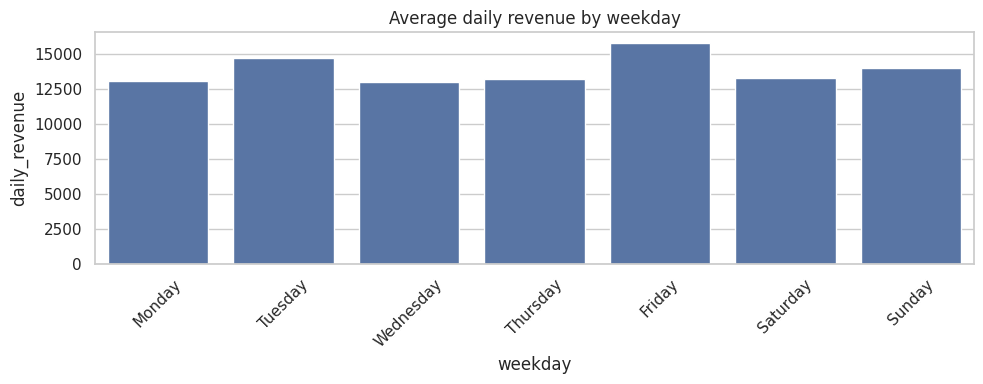

In [31]:
# Daily / weekday trends
sales['transaction_day'] = sales['transaction_date'].dt.date
daily = sales.groupby('transaction_day').agg(daily_revenue=('net_revenue','sum'), orders=('transaction_id' if 'transaction_id' in sales.columns else 'transaction_date','nunique' if 'transaction_id' in sales.columns else 'count')).reset_index()
daily['weekday'] = pd.to_datetime(daily['transaction_day']).dt.day_name()
weekday_avg = daily.groupby('weekday')['daily_revenue'].mean().reindex(['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']).reset_index()
plt.figure(figsize=(10,4))
sns.barplot(data=weekday_avg, x='weekday', y='daily_revenue')
plt.xticks(rotation=45)
plt.title('Average daily revenue by weekday')
plt.tight_layout()
plt.show()

In [32]:
weekday_avg

,weekday,daily_revenue
0,Monday,13077.624980
1,Tuesday,14724.121976
2,Wednesday,13032.390654
3,Thursday,13192.610303
4,Friday,15763.942417
5,Saturday,13298.711141
6,Sunday,13989.906822


### 📊 Findings from Daily Sales Data
- **Highest-performing day:**  
  - **Friday** with ~15,764 in daily revenue (strongest sales day).  
- **Second-highest:**  
  - **Tuesday** with ~14,724.  
- **Moderate performance:**  
  - **Sunday** (~13,990).  
- **Lowest-performing days:**  
  - **Wednesday**  and **Monday**  
- **Observation:**  
  - Sales tend to be stronger **towards the end of the workweek (Friday)** and **early in the week (Tuesday)**.  
  - Mid-week (Wednesday, Thursday) and early-week (Monday) are weaker.  

---

### 🔎 Key Insights
1. **Friday spikes** → customers may shop before the weekend, possibly influenced by promotions or payday cycles.  
2. **Tuesday strength** → could be linked to mid-week online shopping habits or specific campaigns.  
3. **Monday–Thursday dip** → suggests fatigue at start/middle of workweek, with less customer engagement.  
4. **Weekend stability** → Sunday shows moderate performance, not as strong as Friday but better than mid-week.  

---

### 💡 Strategic Recommendations

#### For Low-Performing Days (Monday–Thursday)
- **Targeted Promotions:** Run “Midweek Deals” or “Monday Flash Sales” to stimulate activity.  
- **Loyalty Incentives:** Double loyalty points or offer small discounts for purchases on these days.  
- **Email/SMS Campaigns:** Send personalized recommendations on Monday/Wednesday to nudge customers.  
- **Bundling Strategy:** Introduce product bundles with special pricing midweek.  

#### For High-Performing Days (Friday, Tuesday)
- **Upselling & Cross-Selling:** Promote higher-value products since customers are already more engaged.  
- **Exclusive Launches:** Introduce new product drops or campaigns on high-traffic days to maximize visibility.  
- **Limited-Time Premium Offers:** Encourage higher average order values through time-sensitive promotions.  

---

### ✅ Conclusion
- **High-performing days:** Friday and Tuesday → focus on maximizing revenue through upselling and premium promotions.  
- **Low-performing days:** Monday–Thursday → implement targeted midweek promotions, loyalty incentives, and reminder campaigns to boost activity.  
- By balancing **slow-day boosts with high-day maximization**, the company can smooth sales across the week and drive consistent revenue growth.  
